In [1]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import accuracy_score, f1_score
from matplotlib import font_manager, rcParams

# Path to your font directory
font_dir = "/data1/morrisq/yuj13/share/fonts/liberation-fonts-ttf-2.1.5/"

# Register the font files with Matplotlib
font_manager.fontManager.addfont(font_dir + "LiberationSans-Regular.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Bold.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-Italic.ttf")
font_manager.fontManager.addfont(font_dir + "LiberationSans-BoldItalic.ttf")

# Set Liberation Sans as the default font (Arial-compatible)
rcParams["font.family"] = "Liberation Sans"

In [2]:
BASE_VAF   = '/data1/morrisq/yuj13/llm_genomics/mutation_output/mutation_status_with_chr'
BASE_NOVAF = '/data1/morrisq/yuj13/llm_genomics/mutation_output/mutation_status_with_chr_noVAF'

MODELS = {
    'claude-opus-45': 'Claude Opus 4.5',
    'deepseek':       'DeepSeek',
    'gpt-4o':         'GPT-4o',
    'medgemma':       'MedGemma',
    'qwen3':          'Qwen3',
}

In [3]:
def load_model(base_dir, model_key):
    files = sorted(glob.glob(os.path.join(base_dir, model_key, 'combined_batch_*.csv')))
    return pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

def compute_metrics(df):
    y_true = df['ground_truth']
    y_pred = df['prediction']
    acc = accuracy_score(y_true, y_pred) * 100
    f1  = f1_score(y_true, y_pred, average='weighted') * 100
    return acc, f1

records = []
for model_key, model_label in MODELS.items():
    for base_dir, condition in [(BASE_VAF, 'With VAF'), (BASE_NOVAF, 'No VAF')]:
        df = load_model(base_dir, model_key)
        acc, f1 = compute_metrics(df)
        records.append({'model': model_label, 'condition': condition, 'accuracy': acc, 'f1': f1})
        print(f'{model_label} | {condition}: acc={acc:.2f}%  f1={f1:.2f}%')

results = pd.DataFrame(records)

Claude Opus 4.5 | With VAF: acc=83.26%  f1=83.74%
Claude Opus 4.5 | No VAF: acc=70.94%  f1=71.13%
DeepSeek | With VAF: acc=88.25%  f1=87.82%
DeepSeek | No VAF: acc=76.97%  f1=73.80%
GPT-4o | With VAF: acc=79.65%  f1=77.65%
GPT-4o | No VAF: acc=78.71%  f1=76.60%
MedGemma | With VAF: acc=75.50%  f1=73.43%
MedGemma | No VAF: acc=68.73%  f1=63.37%
Qwen3 | With VAF: acc=89.88%  f1=89.72%
Qwen3 | No VAF: acc=76.80%  f1=74.30%


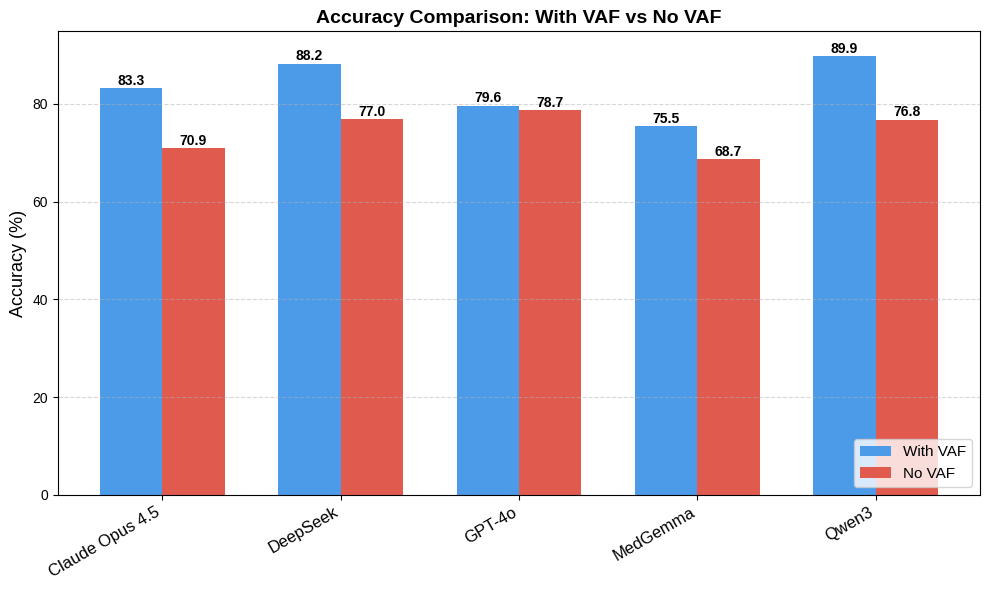

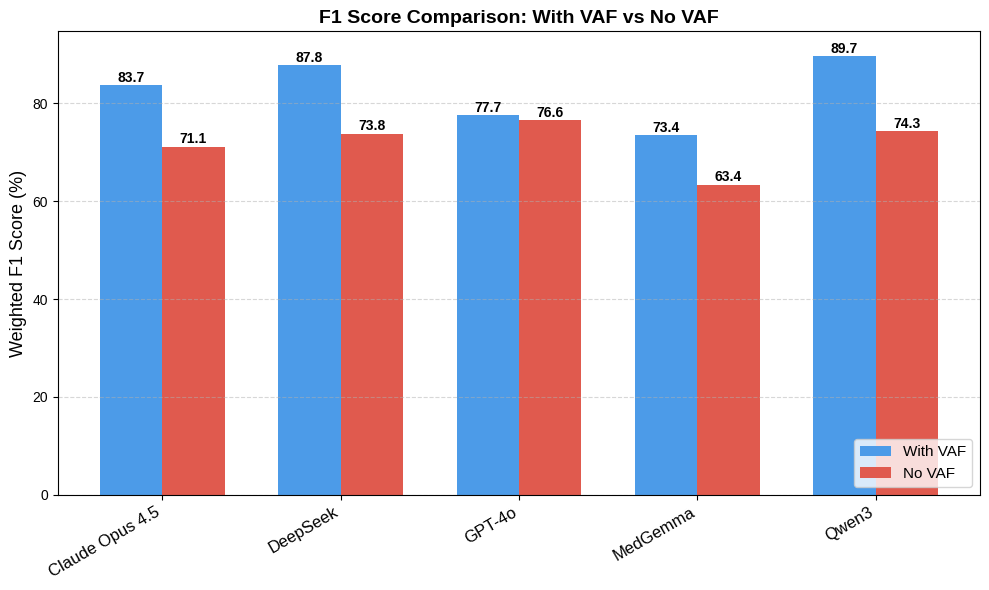

In [7]:
model_order = list(MODELS.values())
conditions  = ['With VAF', 'No VAF']
colors      = {'With VAF': '#4C9BE8', 'No VAF': '#E05A4E'}
x           = np.arange(len(model_order))
width       = 0.35
offset      = {'With VAF': -width / 2, 'No VAF': width / 2}

def make_bar_plot(metric, ylabel, title, filename):
    fig, ax = plt.subplots(figsize=(10, 6))

    for cond in conditions:
        vals = [
            results.loc[(results['model'] == m) & (results['condition'] == cond), metric].values[0]
            for m in model_order
        ]
        bars = ax.bar(x + offset[cond], vals, width, label=cond, color=colors[cond])
        for bar, v in zip(bars, vals):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.05,
                f'{v:.1f}',
                ha='center', va='bottom', fontsize=10, fontweight='bold'
            )

    ax.set_xticks(x)
    ax.set_xticklabels(model_order, rotation=30, ha='right', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=13)
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.legend(fontsize=11, loc='lower right')
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    all_vals = results[metric]
    ax.set_ylim(0, all_vals.max() + 5)

    plt.tight_layout()
    plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()

make_bar_plot('accuracy', 'Accuracy (%)',         'Accuracy Comparison: With VAF vs No VAF',   'vaf_accuracy_barplot.pdf')
make_bar_plot('f1',       'Weighted F1 Score (%)', 'F1 Score Comparison: With VAF vs No VAF',  'vaf_f1_barplot.pdf')